<a href="https://colab.research.google.com/github/Omar-Siddique/Revenue-Transactions-Dataset/blob/main/Revenue_Transaction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Revenue Transactions Dataset**

* To analyze revenue transaction patterns by examining sales performance across different outlets, identifying high-performing locations, and evaluating overall business growth.

* To evaluate sales trends over time by analyzing daily, weekly, and monthly transaction data to identify seasonal demand, peak sales periods, and revenue fluctuations.

* To assess customer purchasing behavior by analyzing transaction frequency, item quantities, average transaction value, and payment method preferences to understand customer buying patterns.

* To measure the contribution of key financial metrics by evaluating Net Sales, Tax, and Total Amount to determine their impact on overall revenue generation and profitability.

* To identify operational performance indicators by examining receipt-level transactions, product quantities, and loyalty card usage to uncover opportunities for improving customer retention and sales efficiency.

* To generate data-driven business insights and
recommendations that support strategic decision-making in sales optimization, revenue forecasting, customer engagement, and operational planning through Python-based data analysis and visualization.





# **Dataset Information**

Source: Mendeley Data – Revenue Transactional Dataset

Location: Surabaya, East Java, Indonesia (Data collected from an anonymized Food & Beverage (F&B) MSME operating multiple retail outlets.)

Year/Timeline: January 2025 – September 2025

Domain: Retail Sales & Revenue Analytics (Food & Beverage Industry)

Dataset Size: 53,820 transaction records, 11 transaction features, and 96 product records across 3 retail outlets.

In [ ]:
#IMPORTING Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
#Data loaded from GitHub

url = "https://raw.githubusercontent.com/Omar-Siddique/Revenue-Transactions-Dataset/refs/heads/main/Revenue%20Transactions%20Dataset.csv"

In [ ]:
#Csv file is converted to datafarme with pandas
df = pd.read_csv(url)


# **Initial Inspection / Initial EDA**

In [ ]:
# displaying first 5 rows
df.head()

,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard
0,SHOP001,02-01-2025,07:01:05,20720.721,2279.279,23000.0,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0
1,SHOP001,02-01-2025,07:04:11,18018.018,1981.982,20000.0,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0
2,SHOP002,02-01-2025,07:10:46,39639.640,4360.360,44000.0,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0
3,SHOP002,02-01-2025,07:14:25,36036.036,3963.964,40000.0,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0
4,SHOP002,02-01-2025,07:23:05,36036.036,3963.964,40000.0,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0


In [ ]:
# To evaluate data health, check for missing values, and monitor memory consumption.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53820 entries, 0 to 53819
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Outlet          53820 non-null  object 
 1   Date            53820 non-null  object 
 2   Time            53820 non-null  object 
 3   NetSales        53820 non-null  float64
 4   Tax             53820 non-null  float64
 5   TotalAmount     53714 non-null  float64
 6   ReceiptNumber   53820 non-null  object 
 7   Items           53820 non-null  object 
 8   TotalItem       53820 non-null  int64  
 9   PaymentMethod   53820 non-null  object 
 10  UseLoyaltyCard  53820 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 4.5+ MB


In [ ]:
#to understand the attribute and to check  the column labels
df.columns

Index(['Outlet', 'Date', 'Time', 'NetSales', 'Tax', 'TotalAmount',
       'ReceiptNumber', 'Items', 'TotalItem', 'PaymentMethod',
       'UseLoyaltyCard'],
      dtype='object')

In [ ]:
#to understand quick statistical summary of your DataFrame
df.describe()

,NetSales,Tax,TotalAmount,TotalItem,UseLoyaltyCard
count,53820.000000,53820.000000,53714.000000,53820.000000,53820.000000
mean,22016.598672,2421.825705,24452.619429,1.151486,0.032200
std,10172.062610,1118.926902,11294.356466,0.358526,0.176532
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,18018.018000,1981.982000,20000.000000,1.000000,0.000000
50%,20720.721000,2279.279000,23000.000000,1.000000,0.000000
75%,27027.027000,2972.973000,30000.000000,1.000000,0.000000
max,54054.054000,5945.946000,60000.000000,2.000000,1.000000


In [ ]:
df.dtypes

,0
Outlet,object
Date,object
Time,object
NetSales,float64
Tax,float64
TotalAmount,float64
ReceiptNumber,object
Items,object
TotalItem,int64
PaymentMethod,object


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Outlet,0
Date,0
Time,0
NetSales,0
Tax,0
TotalAmount,106
ReceiptNumber,0
Items,0
TotalItem,0
PaymentMethod,0


# **Data Cleaning**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Outlet,0
Date,0
Time,0
NetSales,0
Tax,0
TotalAmount,106
ReceiptNumber,0
Items,0
TotalItem,0
PaymentMethod,0


In [ ]:
# Calculate the mean of TotalAmount
mean_total = df['TotalAmount'].mean()

print(mean_total)

24452.61942882675


In [ ]:
# Impute missing values with the mean
df['TotalAmount'] = df['TotalAmount'].fillna(mean_total)

In [ ]:

df.isnull().sum()

,0
Outlet,0
Date,0
Time,0
NetSales,0
Tax,0
TotalAmount,0
ReceiptNumber,0
Items,0
TotalItem,0
PaymentMethod,0


# **Data tranformation**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [ ]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

In [ ]:
df.dtypes

,0
Outlet,object
Date,datetime64[ns]
Time,datetime64[ns]
NetSales,float64
Tax,float64
TotalAmount,float64
ReceiptNumber,object
Items,object
TotalItem,int64
PaymentMethod,object


# **Feature Engineering**

In [ ]:
df ['Month'] = df['Date'].dt.month_name()

df ['Year'] = df['Date'].dt.year

print(df['Month'].head(5))

print(df['Year'].head(5))

0    January
1    January
2    January
3    January
4    January
Name: Month, dtype: object
0    2025
1    2025
2    2025
3    2025
4    2025
Name: Year, dtype: int32


In [ ]:
#Create a new column Sales Category
df['SalesCategory'] = pd.cut(
    df['TotalAmount'],
    bins=[0, 100000, 300000, float('inf')],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

In [ ]:
#Create a new column Average Item Price
df['AverageItemPrice'] = df['TotalAmount'] / df['TotalItem']

In [ ]:
#Create a new column for Customer type
df['CustomerType'] = df['UseLoyaltyCard'].map({
    1: 'Member',
    0: 'Non-Member'
})

In [ ]:
# displaying first 5 rows
df.head()

,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard,Month,Year,SalesCategory,AverageItemPrice,CustomerType
0,SHOP001,2025-01-02,1900-01-01 07:01:05,20720.721,2279.279,23000.0,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0,January,2025,Low,23000.0,Non-Member
1,SHOP001,2025-01-02,1900-01-01 07:04:11,18018.018,1981.982,20000.0,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0,January,2025,Low,20000.0,Non-Member
2,SHOP002,2025-01-02,1900-01-01 07:10:46,39639.640,4360.360,44000.0,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0,January,2025,Low,22000.0,Non-Member
3,SHOP002,2025-01-02,1900-01-01 07:14:25,36036.036,3963.964,40000.0,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0,January,2025,Low,20000.0,Non-Member
4,SHOP002,2025-01-02,1900-01-01 07:23:05,36036.036,3963.964,40000.0,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0,January,2025,Low,20000.0,Non-Member


In [ ]:
# displaying first 5 rows
df.head()

,Outlet,Date,Time,NetSales,Tax,TotalAmount,ReceiptNumber,Items,TotalItem,PaymentMethod,UseLoyaltyCard,Month,Year,SalesCategory,AverageItemPrice,CustomerType
0,SHOP001,2025-01-02,1900-01-01 07:01:05,20720.721,2279.279,23000.0,SHOP001JAN2500001,Basic Latte (Ice Arabica),1,BCA,0,January,2025,Low,23000.0,Non-Member
1,SHOP001,2025-01-02,1900-01-01 07:04:11,18018.018,1981.982,20000.0,SHOP001JAN2500002,BLACK (Houseblend),1,BCA,0,January,2025,Low,20000.0,Non-Member
2,SHOP002,2025-01-02,1900-01-01 07:10:46,39639.640,4360.360,44000.0,SHOP002JAN2500001,"Friendly Coffee (Hot), Shakencano",2,Cash,0,January,2025,Low,22000.0,Non-Member
3,SHOP002,2025-01-02,1900-01-01 07:14:25,36036.036,3963.964,40000.0,SHOP002JAN2500002,"BLACK (Arabica), Americano (Hot Arabica)",2,Cash,0,January,2025,Low,20000.0,Non-Member
4,SHOP002,2025-01-02,1900-01-01 07:23:05,36036.036,3963.964,40000.0,SHOP002JAN2500003,"WHITE (Arabica), Susu Oat",2,Cash,0,January,2025,Low,20000.0,Non-Member


In [ ]:
# To evaluate data health, check for missing values, and monitor memory consumption.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53820 entries, 0 to 53819
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Outlet            53820 non-null  object        
 1   Date              53820 non-null  datetime64[ns]
 2   Time              53820 non-null  datetime64[ns]
 3   NetSales          53820 non-null  float64       
 4   Tax               53820 non-null  float64       
 5   TotalAmount       53820 non-null  float64       
 6   ReceiptNumber     53820 non-null  object        
 7   Items             53820 non-null  object        
 8   TotalItem         53820 non-null  int64         
 9   PaymentMethod     53820 non-null  object        
 10  UseLoyaltyCard    53820 non-null  int64         
 11  Month             53820 non-null  object        
 12  Year              53820 non-null  int32         
 13  SalesCategory     53820 non-null  category      
 14  AverageItemPrice  5382

In [ ]:
#to understand the attribute and to check  the column labels
df.columns

Index(['Outlet', 'Date', 'Time', 'NetSales', 'Tax', 'TotalAmount',
       'ReceiptNumber', 'Items', 'TotalItem', 'PaymentMethod',
       'UseLoyaltyCard', 'Month', 'Year', 'SalesCategory', 'AverageItemPrice',
       'CustomerType'],
      dtype='object')

In [ ]:
#to understand quick statistical summary of your DataFrame
df.describe()

,Date,Time,NetSales,Tax,TotalAmount,TotalItem,UseLoyaltyCard,Year,AverageItemPrice
count,53820,53820,53820.000000,53820.000000,53820.000000,53820.000000,53820.000000,53820.0,53820.000000
mean,2025-05-19 07:41:32.307692288,1900-01-01 15:37:07.502712576,22016.598672,2421.825705,24452.619429,1.151486,0.032200,2025.0,21121.961681
min,2025-01-02 00:00:00,1900-01-01 07:00:02,0.000000,0.000000,0.000000,1.000000,0.000000,2025.0,0.000000
25%,2025-03-10 00:00:00,1900-01-01 11:42:15,18018.018000,1981.982000,20000.000000,1.000000,0.000000,2025.0,20000.000000
50%,2025-05-27 00:00:00,1900-01-01 15:56:17,20720.721000,2279.279000,23000.000000,1.000000,0.000000,2025.0,23000.000000
75%,2025-07-23 00:00:00,1900-01-01 19:34:44.500000,27027.027000,2972.973000,30000.000000,1.000000,0.000000,2025.0,25000.000000
max,2025-09-30 00:00:00,1900-01-01 22:59:59,54054.054000,5945.946000,60000.000000,2.000000,1.000000,2025.0,30000.000000
std,NaN,NaN,10172.062610,1118.926902,11283.228501,0.358526,0.176532,0.0,7131.698790


In [ ]:
df.dtypes

,0
Outlet,object
Date,datetime64[ns]
Time,datetime64[ns]
NetSales,float64
Tax,float64
TotalAmount,float64
ReceiptNumber,object
Items,object
TotalItem,int64
PaymentMethod,object


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Outlet,0
Date,0
Time,0
NetSales,0
Tax,0
TotalAmount,0
ReceiptNumber,0
Items,0
TotalItem,0
PaymentMethod,0


# **Statistical Analysis**

In [ ]:
num_col = [
    'NetSales',
    'Tax',
    'TotalAmount',
    'TotalItem'
]

In [ ]:
summary_table = pd.DataFrame({
    'Mean': df[num_col].mean(),
    'Median': df[num_col].median(),
    'Mode': df[num_col].mode().iloc[0]
})

print("MEASURE OF CENTRAL TENDENCY\n")
print(summary_table)

MEASURE OF CENTRAL TENDENCY

                     Mean     Median       Mode
NetSales     22016.598672  20720.721  27027.027
Tax           2421.825705   2279.279   2972.973
TotalAmount  24452.619429  23000.000  30000.000
TotalItem        1.151486      1.000      1.000


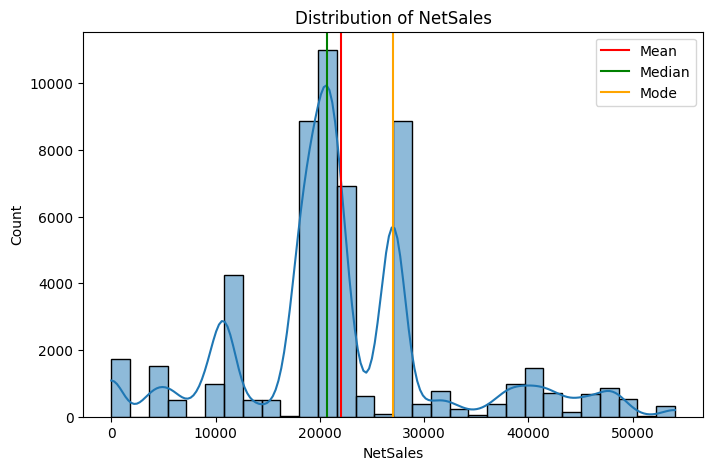

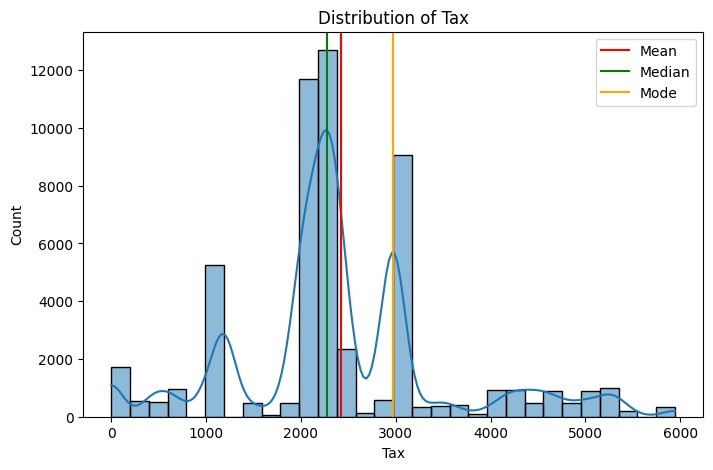

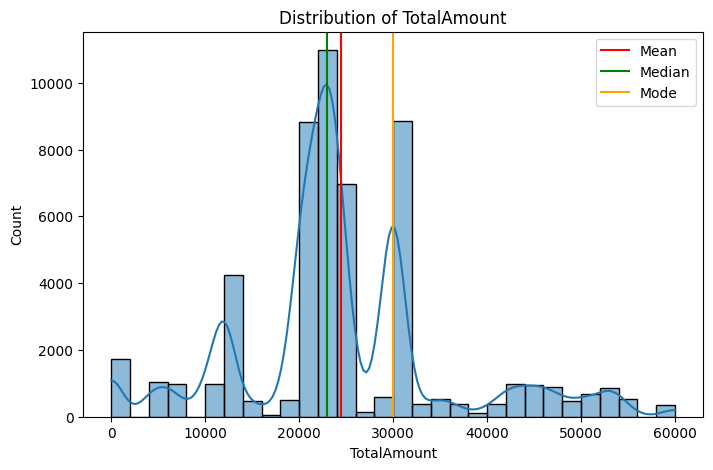

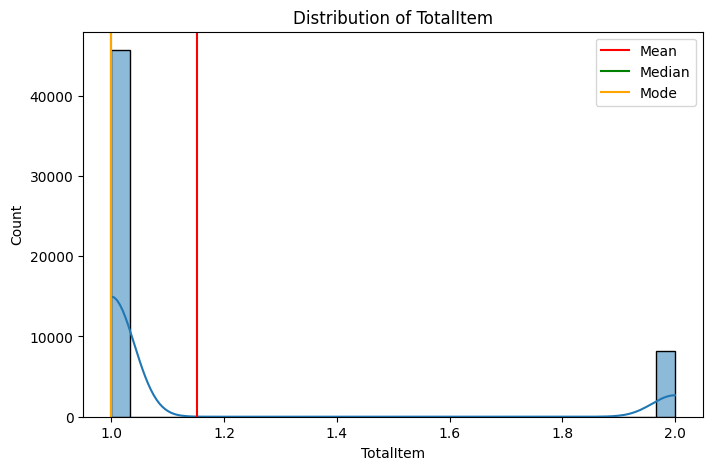

In [ ]:
for col in num_col:

    plt.figure(figsize=(8,5))

    sns.histplot(df[col], bins=30, kde=True)

    plt.axvline(df[col].mean(), color='red', label='Mean')
    plt.axvline(df[col].median(), color='green', label='Median')
    plt.axvline(df[col].mode()[0], color='orange', label='Mode')

    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [ ]:
# Variance
variance_table = df[num_col].var().to_frame(name='Variance')

print("MEASURE OF DISPERSION: VARIANCE\n")
print(variance_table)

MEASURE OF DISPERSION: VARIANCE

                 Variance
NetSales     1.034709e+08
Tax          1.251997e+06
TotalAmount  1.273112e+08
TotalItem    1.285407e-01


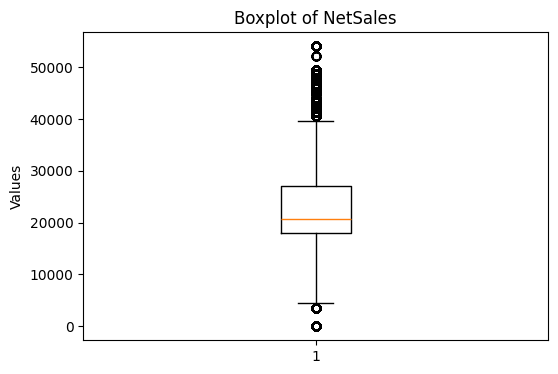

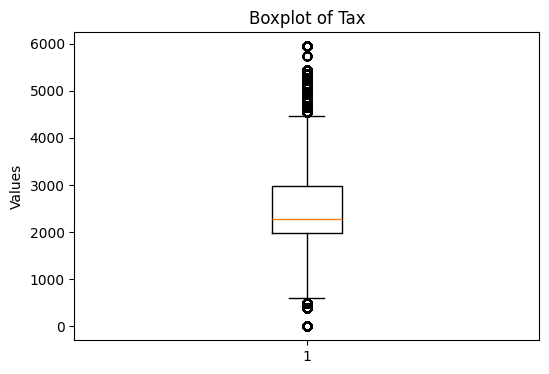

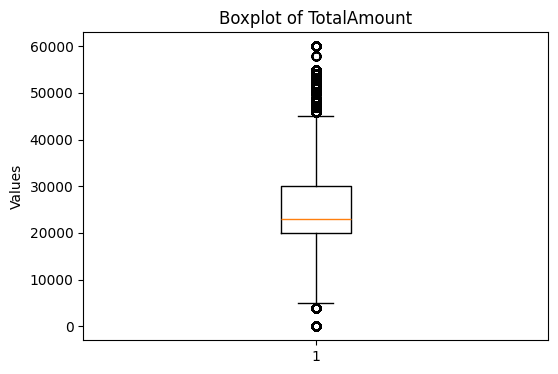

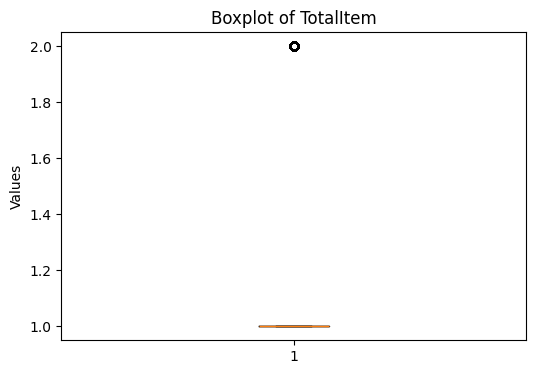

In [ ]:
for col in num_col:
    plt.figure(figsize=(6, 4))

    # Just pass the column directly since there are no empty cells
    plt.boxplot(df[col])

    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')
    plt.show()

The variance analysis indicates that NetSales and TotalAmount have high variability, showing that transaction values differ considerably across customers. Tax also exhibits moderate variation, reflecting differences in purchase amounts, while TotalItem has very low variance, indicating that customers generally purchase a similar number of items per transaction. Overall, the dataset demonstrates noticeable variation in financial metrics, suggesting diverse customer spending patterns and revenue generation across transactions.

In [ ]:
# Standard Deviation
std_table = df[num_col].std().to_frame(name='Standard Deviation')

print("MEASURE OF DISPERSION: STANDARD DEVIATION\n")
print(std_table)

MEASURE OF DISPERSION: STANDARD DEVIATION

             Standard Deviation
NetSales           10172.062610
Tax                 1118.926902
TotalAmount        11283.228501
TotalItem              0.358526


In [ ]:
# Calculate mean for each column
means = df[num_col].mean()
# Deviation from mean
deviation = df[num_col] - means

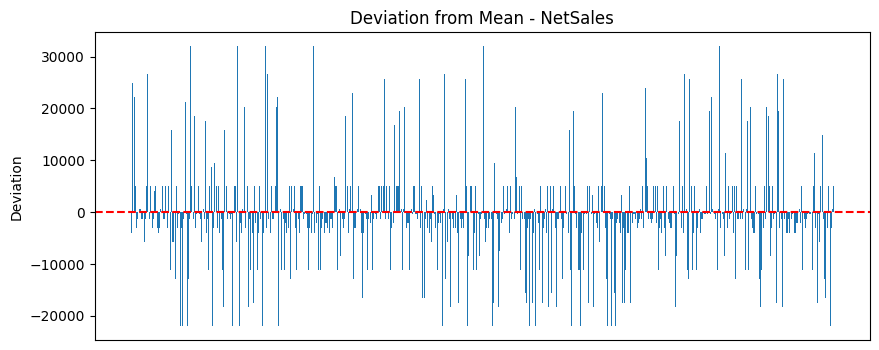

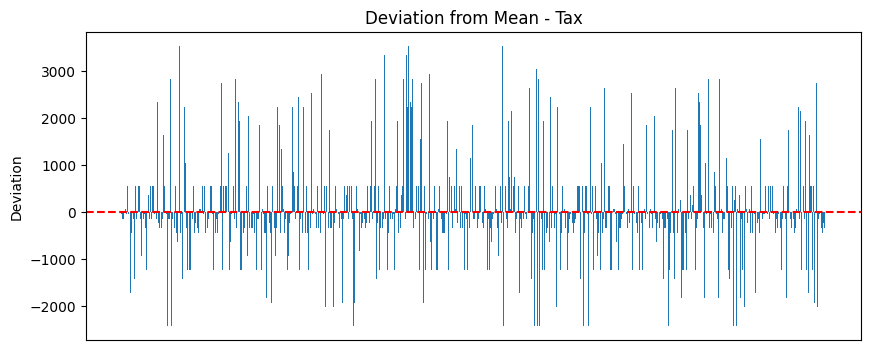

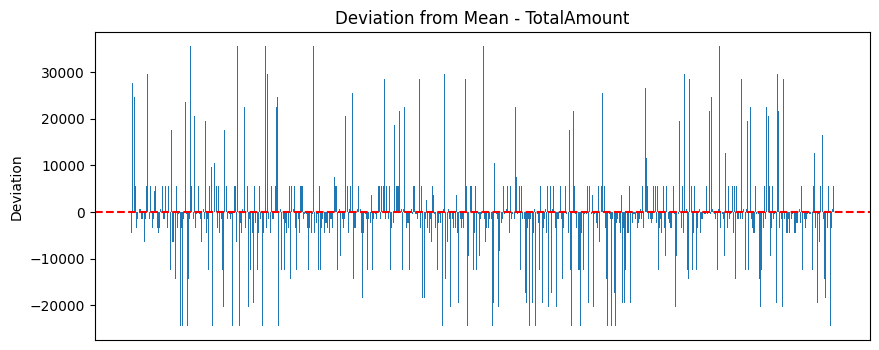

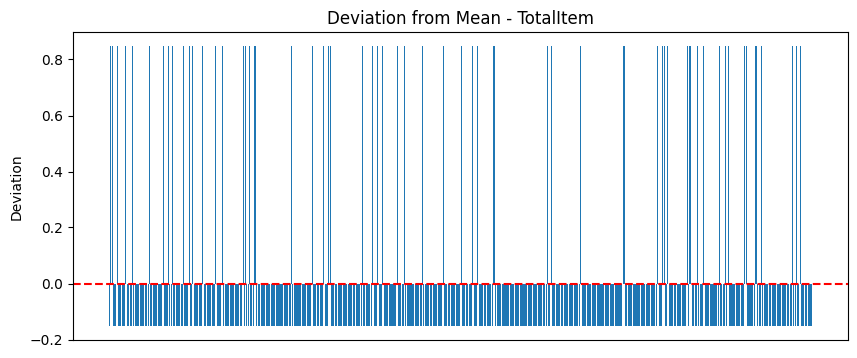

In [ ]:
for col in num_col:
    plt.figure(figsize=(10,4))
    plt.bar(range(len(deviation)), deviation[col])
    plt.axhline(0, color='red', linestyle='--')  # mean line
    plt.title(f'Deviation from Mean - {col}')
    plt.ylabel('Deviation')
    plt.xticks([])  # remove x-axis labels
    plt.show()

The deviation from mean analysis shows that NetSales, Tax, and TotalAmount have noticeable fluctuations around their respective mean values, indicating variability in customer spending and transaction amounts. Several observations deviate substantially from the mean, suggesting the presence of high-value and low-value transactions. In contrast, TotalItem exhibits relatively small deviations, indicating that the number of items purchased per transaction remains fairly consistent. Overall, the analysis highlights that financial variables vary considerably across transactions, while purchasing quantity remains comparatively stable.

# **Data visulaization**

# **Bivariate Analysis**

Outlet vs Average NetSales (Bar Plot)

/tmp/ipykernel_1253/307797552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


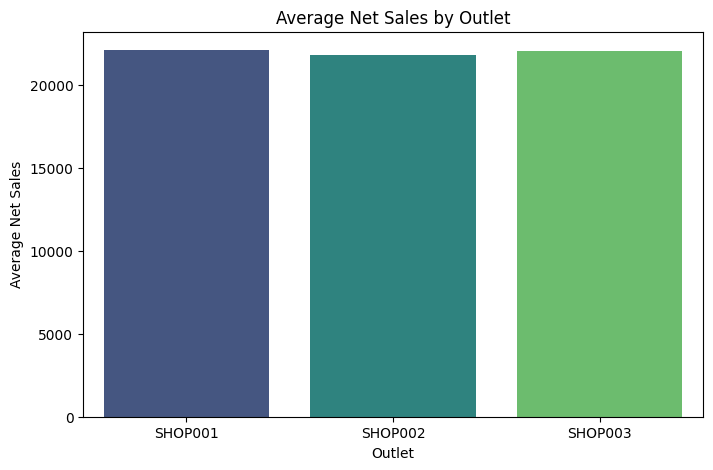

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Outlet',
    y='NetSales',
    estimator='mean',
    errorbar=None,
    palette='viridis'
)

plt.title("Average Net Sales by Outlet")
plt.xlabel("Outlet")
plt.ylabel("Average Net Sales")

plt.show()

Interpretation

Identifies high-performing outlets based on average Net Sales.
Outlets with higher average sales contribute more to overall revenue.

# **Bivariate Analysis**

Monthly Sales Trend (Line Chart)

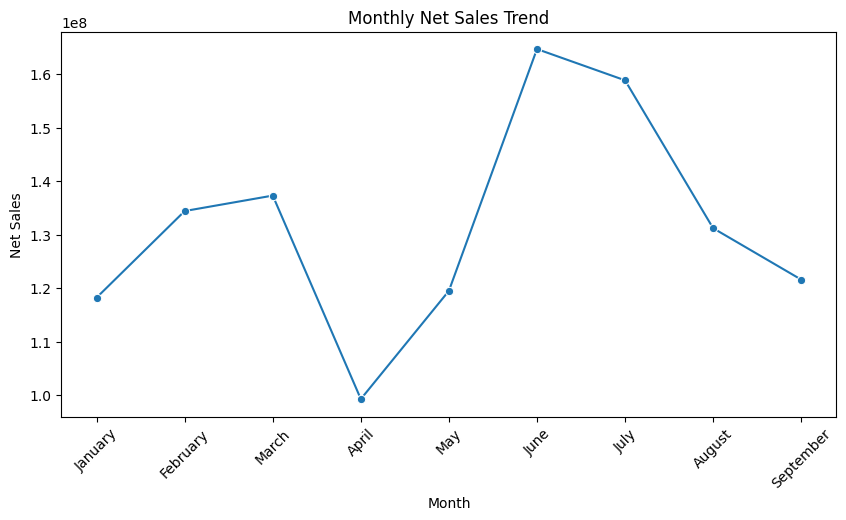

In [ ]:
monthly_sales = df.groupby('Month')['NetSales'].sum().reset_index()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('Month')

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='NetSales',
    marker='o'
)

plt.title("Monthly Net Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales")

plt.xticks(rotation=45)

plt.show()

Interpretation

Shows monthly sales trends.
Helps identify seasonal demand and peak revenue periods.

# **Bivariate Analysis**

TotalItem vs NetSales (Scatter Plot)

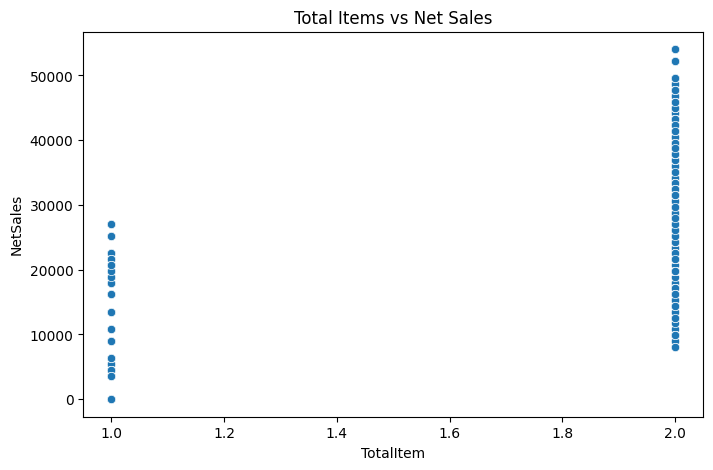

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='TotalItem',
    y='NetSales'
)

plt.title("Total Items vs Net Sales")

plt.show()

Interpretation

Identifies the most preferred payment method among customers.

# **Multivariate Analysis**

Correlation Heatmap

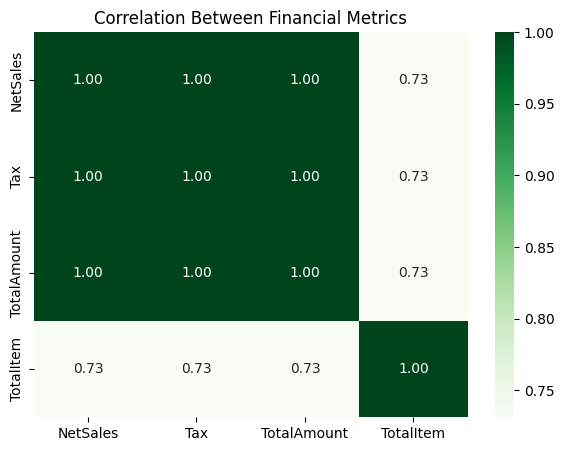

In [ ]:
plt.figure(figsize=(7,5))

corr = df[['NetSales','Tax','TotalAmount','TotalItem']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Greens',
    fmt='.2f'
)

plt.title("Correlation Between Financial Metrics")

plt.show()

Interpretation

Shows relationships among financial metrics.
Strong positive correlations indicate variables contributing to revenue.

# **Multivariate Analysis**

Outlet × Payment Method × TotalAmount

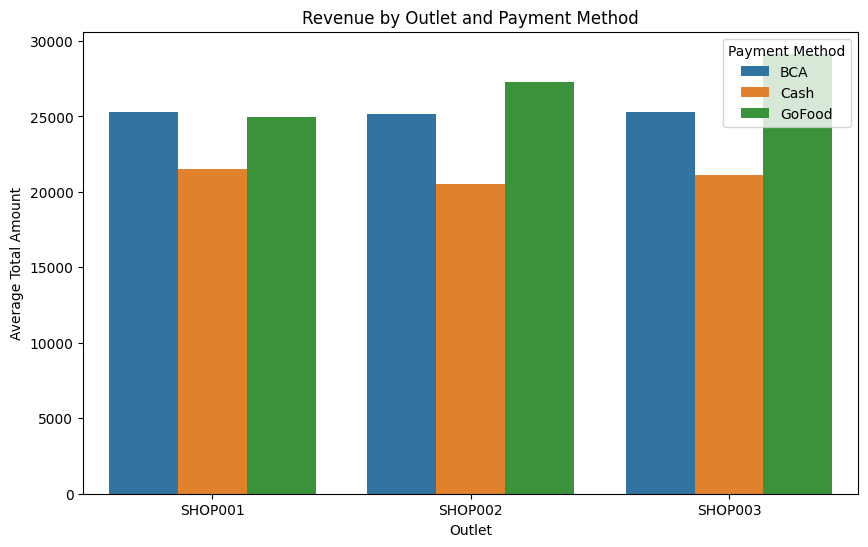

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Outlet',
    y='TotalAmount',
    hue='PaymentMethod',
    estimator='mean',
    errorbar=None
)

plt.title("Revenue by Outlet and Payment Method")

plt.xlabel("Outlet")
plt.ylabel("Average Total Amount")

plt.legend(title="Payment Method")

plt.show()

Interpretation

Compares average revenue generated by different payment methods across outlets.
Helps identify the most effective payment methods for each outlet.